## Module 2 Part B — Predictive modeling, continuing from the same cleaned data

## Part B.7 

## Task 8 - Stratified Train/Test Split (before preprocessing)

## Data Preparation (reproducing Task 2's cleaning in this notebook)

Note: `01_eda.ipynb` and this notebook are separate Jupyter sessions and do not share memory.
This section reloads `titanic.csv` (not `sns.load_dataset` again) and re-applies the exact
same cleaning decisions already justified and verified in `01_eda.ipynb` Task 2. No new
cleaning decisions are made here.

In [1]:
#c2. Load the raw CSV (not the Seaborn loader)
import pandas as pd

df_raw = pd.read_csv("titanic.csv")
print(f"Loaded titanic.csv: {df_raw.shape}")

Loaded titanic.csv: (891, 15)


In [2]:
#c3. Reproduce Task 2's cleaning exactly
 
# Identical logic to 01_eda.ipynb Task 2 - see that notebook for full justification.
df_model = df_raw.copy()

# embarked/embark_town: <5% missing -> drop rows
df_model = df_model.dropna(subset=["embarked", "embark_town"])

# age: 19.87% missing -> median imputation
age_median = df_model["age"].median()
df_model["age"] = df_model["age"].fillna(age_median)

# deck: 77.22% missing -> encode as "Unknown"
df_model["deck"] = df_model["deck"].astype(object).fillna("Unknown")

print(f"df_model shape after cleaning: {df_model.shape}")
print(f"Remaining missing values: {df_model.isnull().sum().sum()}")

df_model shape after cleaning: (889, 15)
Remaining missing values: 0


In [3]:
#c4. Sanity check against Task 2's already-verified result

# This should match 01_eda.ipynb's df_clean exactly: (889, 15), zero missing values
expected_shape = (889, 15)
assert df_model.shape == expected_shape, f"Shape mismatch! Got {df_model.shape}, expected {expected_shape}"
assert df_model.isnull().sum().sum() == 0, "Unexpected missing values remain"
print("Cleaning reproduced correctly - matches Task 2's verified result.")

Cleaning reproduced correctly - matches Task 2's verified result.


## Train/Test Split

Performed **before** any preprocessing (encoding, scaling) to prevent data leakage -
no information from the test set should influence how we encode or scale features.

**Stratified** on `survived` so both the training and test sets preserve the same
survival rate (~38%) as the full dataset, rather than risking an imbalanced split by chance.

In [4]:
#c6. The split itself

from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["survived"])
y = df_model["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,       # fixed seed so the split is reproducible on every run
    stratify=y              # preserves the survival-rate proportion in both sets
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Training set survival rate: {y_train.mean():.4f}")
print(f"Test set survival rate: {y_test.mean():.4f}")
print(f"Full dataset survival rate: {y.mean():.4f}")

X_train shape: (711, 14)
X_test shape: (178, 14)
Training set survival rate: 0.3826
Test set survival rate: 0.3820
Full dataset survival rate: 0.3825


## Part B.8

## Task 9 - Preprocessing Fit on Train Only

## Feature Selection

`X_train`/`X_test` currently contain 14 columns, but several are redundant recodings
of other columns or direct leakage of the target, so we select a deliberate subset:

**Selected features:** `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`
(the 7 standard predictive features)

**Excluded, and why:**
- `alive` - a text version of `survived` itself (e.g. "yes"/"no"). Using this would be
  direct target leakage - the model would just be reading the answer.
- `class`, `who`, `adult_male` - redundant recodings of `pclass`/`sex`/`age` already
  captured by the selected features.
- `alone` - directly derivable from `sibsp`+`parch` (already included).
- `embark_town` - redundant with `embarked` (same information, different format).
- `deck` - despite being usefully encoded as "Unknown" in Task 2, it is excluded here
  as a deliberate simplicity choice for the required model set, not a silent omission.

In [5]:
#c8. select the columns

selected_features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]

X_train_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

print(f"X_train_selected shape: {X_train_selected.shape}")
print(f"X_test_selected shape: {X_test_selected.shape}")

X_train_selected shape: (711, 7)
X_test_selected shape: (178, 7)


## Preprocessing Pipeline

Two separate mini-pipelines, combined into one `ColumnTransformer`:

- **Numeric features** (`pclass`, `age`, `sibsp`, `parch`, `fare`): impute any missing
  values with the median, then scale with `StandardScaler`.
- **Categorical features** (`sex`, `embarked`): impute any missing values with the most
  frequent value, then one-hot encode.

**Critical rule:** `.fit_transform()` is called only on `X_train_selected`. `X_test_selected`
only ever gets `.transform()` (never `.fit()`), so no information from the test set
leaks into how values are imputed, scaled, or encoded.

In [6]:
#c10. Build the columntransformer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [7]:
#c11. Fit on train only, transform both

# FIT_TRANSFORM on training data only - this is where parameters (medians,
# scaling factors, category lists) are LEARNED
X_train_processed = preprocessor.fit_transform(X_train_selected)

# TRANSFORM ONLY on test data - reuses the parameters already learned from
# training, never re-learns anything from test data
X_test_processed = preprocessor.transform(X_test_selected)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

X_train_processed shape: (711, 10)
X_test_processed shape: (178, 10)


In [8]:
#c12. Verification

# Confirm the output column count makes sense:
# 5 numeric columns (scaled, same count) + one-hot encoded categorical columns
feature_names = preprocessor.get_feature_names_out()
print(f"Total output features: {len(feature_names)}")
print(f"Feature names: {list(feature_names)}")

# Sanity check: scaled numeric columns in the TRAINING set should have
# mean ~0 and std ~1, since StandardScaler was fit on this exact data
import numpy as np
X_train_processed_array = np.asarray(X_train_processed)
print(f"\nTraining set processed data - mean of first column (pclass, scaled): {X_train_processed_array[:, 0].mean():.4f}")
print(f"Training set processed data - std of first column (pclass, scaled): {X_train_processed_array[:, 0].std():.4f}")

Total output features: 10
Feature names: ['num__pclass', 'num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S']

Training set processed data - mean of first column (pclass, scaled): -0.0000
Training set processed data - std of first column (pclass, scaled): 1.0000


## Part B.9

## Task 10 — Train 3 Classifiers : Logistic Regression, Decision Tree, Random Forest on same split; visualize Decision Tree with plot_tree.

## All trained on the identical `X_train_processed` / `y_train` data so they are fairly comparable.

In [9]:
#c14. Imports and training


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# random_state=42 used on every model for reproducibility - same reason as the train/test split
log_reg_model = LogisticRegression(random_state=42)
decision_tree_model = DecisionTreeClassifier(random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)

log_reg_model.fit(X_train_processed, y_train)
decision_tree_model.fit(X_train_processed, y_train)
random_forest_model.fit(X_train_processed, y_train)

print("All 3 models trained successfully.")
print(f"Logistic Regression: {log_reg_model}")
print(f"Decision Tree: {decision_tree_model}")
print(f"Random Forest: {random_forest_model}")

All 3 models trained successfully.
Logistic Regression: LogisticRegression(random_state=42)
Decision Tree: DecisionTreeClassifier(random_state=42)
Random Forest: RandomForestClassifier(random_state=42)


### Decision Tree Visualization

Visualizing the trained Decision Tree with `plot_tree`, using the actual feature names
from Task 9's `ColumnTransformer` output so the diagram is readable rather than showing
generic "X[0]", "X[1]" labels.

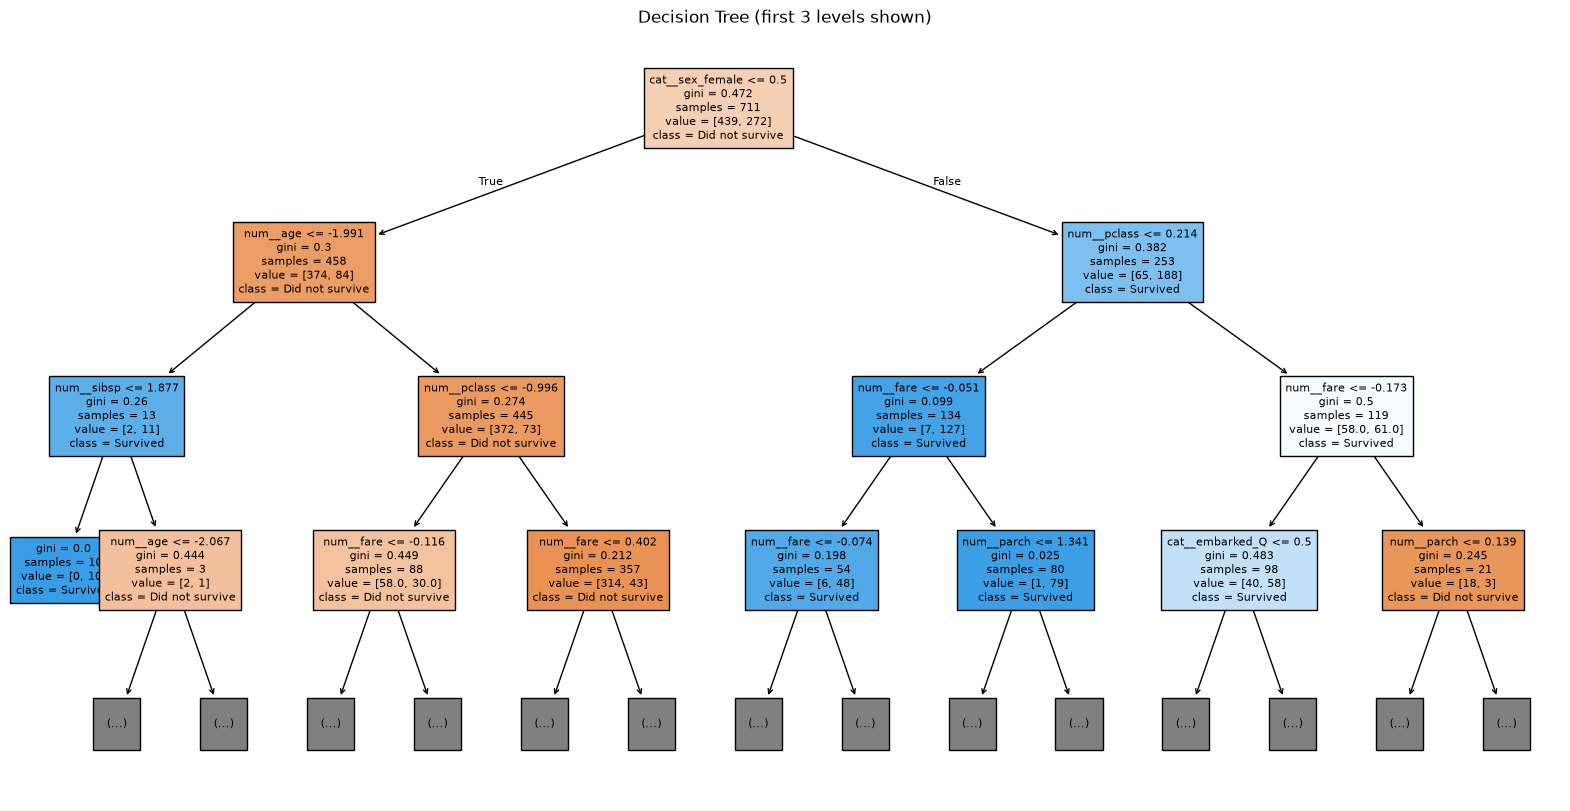

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree (first 3 levels shown)")
plt.show()

In [11]:
#c17. Basic training confirmation

# Quick sanity check only - confirms each model can actually produce predictions.
# Full metrics (accuracy, precision, recall, F1, ROC/AUC, comparison table) are
# a separate task (M2.14), not covered here.
for name, model in [
    ("Logistic Regression", log_reg_model),
    ("Decision Tree", decision_tree_model),
    ("Random Forest", random_forest_model),
]:
    train_predictions = model.predict(X_train_processed)
    print(f"{name}: produced {len(train_predictions)} predictions on training data (sanity check only)")

Logistic Regression: produced 711 predictions on training data (sanity check only)
Decision Tree: produced 711 predictions on training data (sanity check only)
Random Forest: produced 711 predictions on training data (sanity check only)


## Part B.10

## Task 11 — Model Evaluation
Evaluate Logistic Regression, Decision Tree, and Random Forest on the held-out test set using confusion matrices, accuracy, precision, recall, F1-score, and ROC-AUC.

All evaluation metrics below are calculated using `X_test_processed` and `y_test`, which were not used to fit the models.

In [12]:
#c19. Generate test-set predictions

model_predictions = {}
for name, model in [
    ("Logistic Regression", log_reg_model),
    ("Decision Tree", decision_tree_model),
    ("Random Forest", random_forest_model),
]:
    model_predictions[name] = model.predict(X_test_processed)
    print(f"{name}: generated {len(model_predictions[name])} test predictions")

Logistic Regression: generated 178 test predictions
Decision Tree: generated 178 test predictions
Random Forest: generated 178 test predictions


In [13]:
#c20. Generate probability scores(needed for ROC-AUC)

model_probabilities = {}
for name, model in [
    ("Logistic Regression", log_reg_model),
    ("Decision Tree", decision_tree_model),
    ("Random Forest", random_forest_model),
]:
    # predict_proba returns [P(class 0), P(class 1)] - we want P(survived=1), the second column
    model_probabilities[name] = model.predict_proba(X_test_processed)[:, 1]
    print(f"{name}: generated {len(model_probabilities[name])} probability scores")

Logistic Regression: generated 178 probability scores
Decision Tree: generated 178 probability scores
Random Forest: generated 178 probability scores


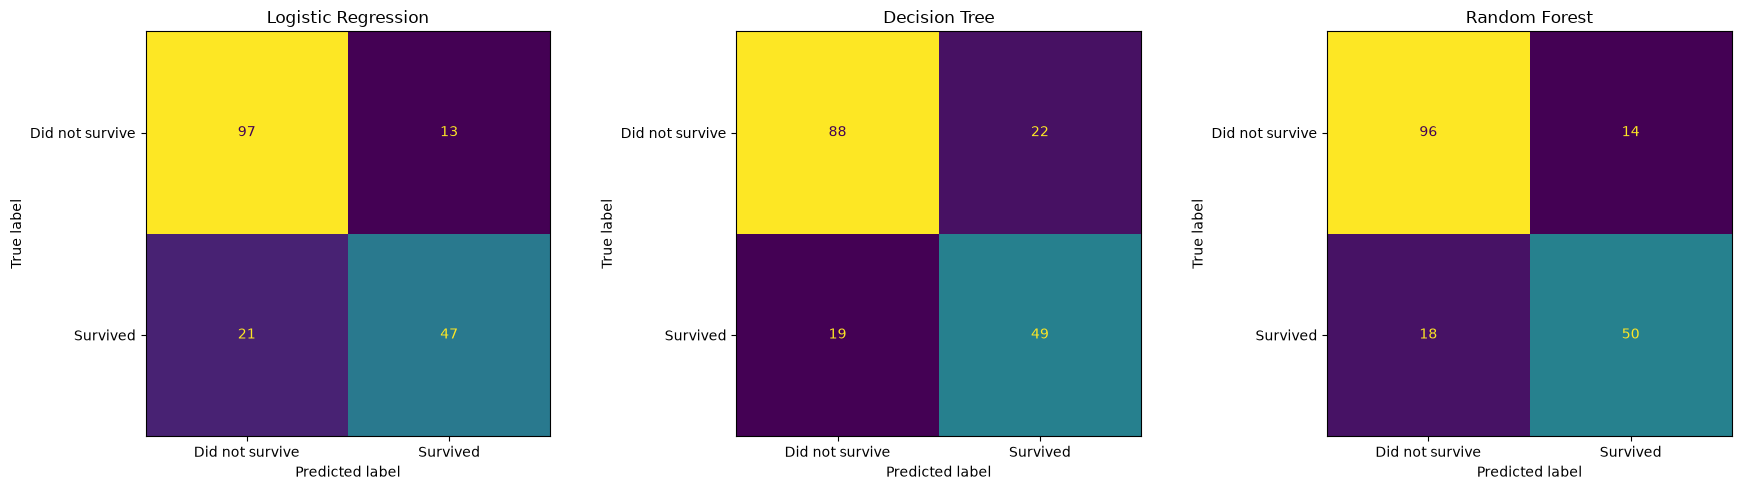

In [14]:
#c21. Confusion matrices

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, predictions) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did not survive", "Survived"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [15]:
#c22. Accuracy, precision, recall, F1 for all 3 models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []
for name, predictions in model_predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, model_probabilities[name]),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.808989   0.783333 0.691176  0.734375 0.860963
      Decision Tree  0.769663   0.690141 0.720588  0.705036 0.754144
      Random Forest  0.820225   0.781250 0.735294  0.757576 0.817914


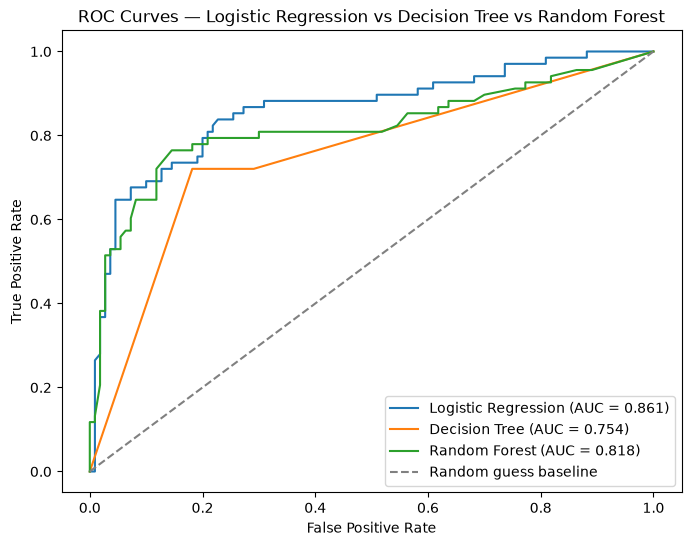

In [38]:
#c23. ROC curves, all 3 models on one plot

from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_score = roc_auc_score(y_test, probabilities)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess baseline")
plt.title("ROC Curves — Logistic Regression vs Decision Tree vs Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("charts/roc_curves.png", dpi=150, bbox_inches="tight")   # ADD THIS LINE
plt.show()

Task 11 — Interpretation

Random Forest achieves the highest accuracy (0.8202) and the highest F1-score (0.7576), making it the best-balanced performer of the three. Logistic Regression achieves the highest ROC-AUC (0.8610), meaning it ranks positive and negative cases most reliably across all possible classification thresholds, even though its default-threshold accuracy is slightly lower than Random Forest's. On the precision/recall trade-off: Logistic Regression favors precision (0.7833) over recall (0.6912) — it is more conservative about predicting "survived," missing more true survivors but making fewer false claims — while Decision Tree favors recall (0.7206) over precision (0.6901), catching more true survivors at the cost of more false alarms; Random Forest sits between the two (0.7813 precision, 0.7353 recall), which is reflected in its leading F1-score. Overall, Random Forest appears the strongest general-purpose model here, combining the best accuracy and F1 with a solid, well-balanced precision/recall trade-off, though Logistic Regression remains a strong alternative if threshold-independent ranking quality (AUC) is the priority.

## Part B.11

## Task 12 — Imbalance Handling Comparison

Using Random Forest (per the spec, any one of the three models is sufficient for this sub-task).
Compares baseline (no handling), `class_weight='balanced'`, and SMOTE oversampling
(applied only to the training fold, to avoid leakage) on precision/recall/F1.

In [17]:
#c26. Reprt class balance

class_counts = y_train.value_counts()
class_percentages = y_train.value_counts(normalize=True) * 100

print("Training set class balance:")
print(f"Did not survive (0): {class_counts[0]} ({class_percentages[0]:.2f}%)")
print(f"Survived (1): {class_counts[1]} ({class_percentages[1]:.2f}%)")

Training set class balance:
Did not survive (0): 439 (61.74%)
Survived (1): 272 (38.26%)


In [18]:
#c27. Variant (a): Baseline, no handling

from sklearn.metrics import precision_score, recall_score, f1_score

rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_processed, y_train)
baseline_predictions = rf_baseline.predict(X_test_processed)

baseline_results = {
    "Precision": precision_score(y_test, baseline_predictions),
    "Recall": recall_score(y_test, baseline_predictions),
    "F1-Score": f1_score(y_test, baseline_predictions),
}
print(f"(a) Baseline: {baseline_results}")

(a) Baseline: {'Precision': 0.78125, 'Recall': 0.7352941176470589, 'F1-Score': 0.7575757575757576}


In [19]:
#c28. Variant (b): class_weight='balanced'

rf_balanced = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_balanced.fit(X_train_processed, y_train)
balanced_predictions = rf_balanced.predict(X_test_processed)

balanced_results = {
    "Precision": precision_score(y_test, balanced_predictions),
    "Recall": recall_score(y_test, balanced_predictions),
    "F1-Score": f1_score(y_test, balanced_predictions),
}
print(f"(b) class_weight='balanced': {balanced_results}")

(b) class_weight='balanced': {'Precision': 0.7391304347826086, 'Recall': 0.75, 'F1-Score': 0.7445255474452555}


In [20]:
#c29. Variant (c): SMOTE, applied only to the training fold

from imblearn.over_sampling import SMOTE

# SMOTE is fit ONLY on X_train_processed/y_train - the test set is never touched
# by SMOTE, which is exactly what prevents leakage here.
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f"Training set size before SMOTE: {X_train_processed.shape[0]}")
print(f"Training set size after SMOTE: {X_train_smote.shape[0]}")
print(f"Class balance after SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
smote_predictions = rf_smote.predict(X_test_processed)  # test set is untouched, still original

smote_results = {
    "Precision": precision_score(y_test, smote_predictions),
    "Recall": recall_score(y_test, smote_predictions),
    "F1-Score": f1_score(y_test, smote_predictions),
}
print(f"(c) SMOTE: {smote_results}")

Training set size before SMOTE: 711
Training set size after SMOTE: 878
Class balance after SMOTE: {1: 439, 0: 439}
(c) SMOTE: {'Precision': 0.746031746031746, 'Recall': 0.6911764705882353, 'F1-Score': 0.7175572519083969}


In [21]:
#c30. Comparison Table

imbalance_comparison = pd.DataFrame([
    {"Strategy": "(a) Baseline", **baseline_results},
    {"Strategy": "(b) class_weight=balanced", **balanced_results},
    {"Strategy": "(c) SMOTE", **smote_results},
])
print(imbalance_comparison.to_string(index=False))

                 Strategy  Precision   Recall  F1-Score
             (a) Baseline   0.781250 0.735294  0.757576
(b) class_weight=balanced   0.739130 0.750000  0.744526
                (c) SMOTE   0.746032 0.691176  0.717557


### Task 12 — Interpretation

Baseline achieved the highest F1-score (0.7576) and highest precision (0.7813), while `class_weight='balanced'` achieved the highest recall (0.7500) at a modest cost to precision (0.7391). SMOTE performed worst on all three metrics (Precision 0.7460, Recall 0.6912, F1 0.7176), despite perfectly balancing the training classes (439/439) — likely because Random Forest already handles moderate imbalance (62/38) reasonably well on its own, so SMOTE's synthetic minority samples may have introduced noise without adding genuinely new information. Overall, `class_weight='balanced'` appears the most useful strategy if recall (catching more true survivors) is the priority, while the plain baseline remains the strongest choice if overall precision/F1 balance matters most — SMOTE does not appear worthwhile for this particular dataset and model combination.

combine both these interpretation by checking the results again and give the better version by including this.

### Task 12 — Your Interpretation

Baseline achieved the highest F1-score (0.7576) and highest precision (0.7813), while `class_weight='balanced'` achieved the highest recall (0.7500) at a modest cost to precision (0.7391). SMOTE performed worst on all three metrics (Precision 0.7460, Recall 0.6912, F1 0.7176), despite perfectly balancing the training classes (439/439) — likely because Random Forest already handles moderate imbalance (62/38) reasonably well on its own, so SMOTE's synthetic minority samples may have introduced noise without adding genuinely new information. Overall, `class_weight='balanced'` appears the most useful strategy if recall (catching more true survivors) is the priority, while the plain baseline remains the strongest choice if overall precision/F1 balance matters most — SMOTE does not appear worthwhile for this particular dataset and model combination.

### Task 12 — Chatgpt's Interpretation

The baseline Random Forest achieved the highest overall F1-score (0.758) and the highest precision (0.781), while class weighting produced the highest recall (0.750). Class weighting therefore improved recall slightly over the baseline (0.735) but reduced precision (0.739), resulting in a lower F1-score (0.745). SMOTE did not improve the results in this experiment: its recall decreased to 0.691 and its F1-score to 0.718. Overall, the baseline Random Forest performed best on the precision/recall/F1 balance for this dataset, while class weighting was preferable only if prioritizing recall over precision.

## Part B.12

## Task 13 — Random Forest Hyperparameter Tuning

GridSearchCV over `n_estimators`, `max_depth`, and `max_features`. `oob_score=True` is set
at construction so the out-of-bag score is available on the best estimator afterward.

Note: the official requirement does not specify a cross-validation fold count or scoring
metric for this task, so GridSearchCV's defaults are used (5-fold CV, accuracy scoring).
Tuning is performed on `X_train_processed`/`y_train` only — `X_test_processed`/`y_test`
are not used anywhere in this task, matching the official requirement, which asks only
for the best parameter combination and OOB score.

In [22]:
#c33. Define the grid and run GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "max_features": ["sqrt", "log2"],
}

# oob_score=True is required at construction time for oob_score_ to be available later.
# bootstrap=True is the default for RandomForestClassifier and is required for OOB scoring.
rf_for_tuning = RandomForestClassifier(oob_score=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    cv=5,          # not specified by the spec; using GridSearchCV's standard default
)

# Fit on TRAINING DATA ONLY - X_test_processed/y_test are never referenced in this cell
grid_search.fit(X_train_processed, y_train)

print("GridSearchCV complete.")

GridSearchCV complete.


In [25]:
#c34. Report the required outputs: best parameters and OOB score

best_rf_model = grid_search.best_estimator_

print(f"Best parameter combination: {grid_search.best_params_}")
print(f"Best cross-validation score (accuracy, training folds only): {grid_search.best_score_:.4f}")
print(f"Out-of-bag (OOB) score of best model: {best_rf_model.oob_score_:.4f}")

Best parameter combination: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 300}
Best cross-validation score (accuracy, training folds only): 0.8200
Out-of-bag (OOB) score of best model: 0.8214


## Part B.13

## Task 14 – Regression side-task : Predicting Fare

Reuses the existing Task 8 train/test row split (same indices) — no new random split introduced.
Feature list and Adjusted R² convention are implementation choices, not specified by the
official document; both are noted in code comments below.

In [26]:
#c36. feature/target setup, reusing existing split indices

# Implementation choice: feature set for predicting fare (not specified by the official doc)
reg_features = ["pclass", "sex", "age", "sibsp", "parch", "embarked", "survived"]

# Reuses the SAME row split as Task 8 (X_train.index / X_test.index) - no new split created
X_train_reg_raw = df_model.loc[X_train.index, reg_features].copy()
X_test_reg_raw = df_model.loc[X_test.index, reg_features].copy()
y_train_reg = df_model.loc[X_train.index, "fare"]
y_test_reg = df_model.loc[X_test.index, "fare"]

print(f"X_train_reg_raw shape: {X_train_reg_raw.shape}")
print(f"X_test_reg_raw shape: {X_test_reg_raw.shape}")

X_train_reg_raw shape: (711, 7)
X_test_reg_raw shape: (178, 7)


In [27]:
#c37. preprocessing, fit on train only

numeric_reg_features = ["pclass", "age", "sibsp", "parch", "survived"]
categorical_reg_features = ["sex", "embarked"]

reg_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_reg_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), categorical_reg_features),
])

X_train_reg_processed = reg_preprocessor.fit_transform(X_train_reg_raw)
X_test_reg_processed = reg_preprocessor.transform(X_test_reg_raw)

print(f"X_train_reg_processed shape: {X_train_reg_processed.shape}")
print(f"X_test_reg_processed shape: {X_test_reg_processed.shape}")

X_train_reg_processed shape: (711, 10)
X_test_reg_processed shape: (178, 10)


In [28]:
#c38. fit LinearRegression, predict

from sklearn.linear_model import LinearRegression

fare_reg_model = LinearRegression()
fare_reg_model.fit(X_train_reg_processed, y_train_reg)
fare_predictions = fare_reg_model.predict(X_test_reg_processed)

print("LinearRegression fitted and predictions generated on test set.")

LinearRegression fitted and predictions generated on test set.


In [29]:
#c39. required metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_reg, fare_predictions)
rmse = np.sqrt(mean_squared_error(y_test_reg, fare_predictions))
r2 = r2_score(y_test_reg, fare_predictions)

n = X_test_reg_processed.shape[0]
p = X_test_reg_processed.shape[1]  # implementation choice: encoded design-matrix column count
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")

MAE: 19.7531
RMSE: 41.2701
R²: 0.3471
Adjusted R²: 0.3081


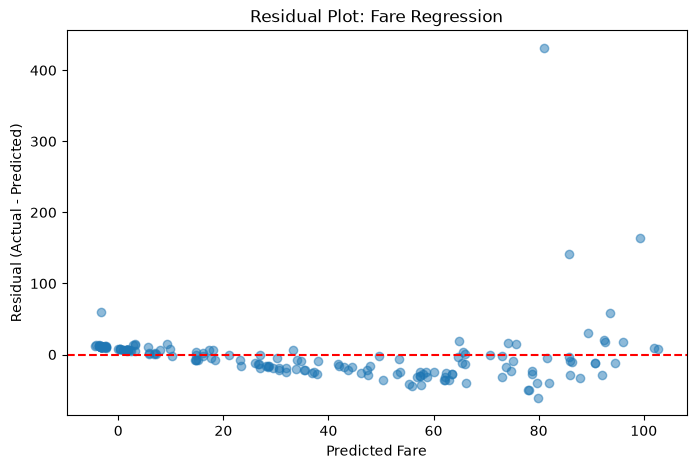

In [30]:
#c40. residual plot

residuals = y_test_reg - fare_predictions

plt.figure(figsize=(8, 5))
plt.scatter(fare_predictions, residuals, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residual Plot: Fare Regression")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()

### Task 14 — Heteroscedasticity Interpretation

The residual plot shows clear heteroscedasticity: residuals are tightly clustered near zero for lower predicted fares (roughly below £20-30), but the spread widens substantially as predicted fare increases, including one large outlier residual of approximately +430 near a predicted fare of £80. This fan-shaped, non-constant spread — rather than a uniform band across all predicted values — indicates the model's errors are not evenly distributed, consistent with the relatively modest R² (0.3471) and Adjusted R² (0.3081): a linear model captures only a moderate share of fare's variance, and its errors grow larger and more variable for the small number of very expensive, likely first-class tickets in the dataset.

## Part B.14

## Task 15 — Final Model Comparison Table and Recommendation

Presented as two separate metric-group tables (classification vs. regression), since the
two metric types are on different scales and not directly comparable.

In [34]:
#c43. two separate tables

print("Classification Models (accuracy, precision, recall, F1, AUC):")
print(results_df.to_string(index=False))

regression_results_df = pd.DataFrame([{
    "Model": "Linear Regression (predicting fare)",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Adjusted_R2": adjusted_r2,
}])

print("\nRegression Model (MAE, RMSE, R², Adjusted R²):")
print(regression_results_df.to_string(index=False))

Classification Models (accuracy, precision, recall, F1, AUC):
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.808989   0.783333 0.691176  0.734375 0.860963
      Decision Tree  0.769663   0.690141 0.720588  0.705036 0.754144
      Random Forest  0.820225   0.781250 0.735294  0.757576 0.817914

Regression Model (MAE, RMSE, R², Adjusted R²):
                              Model       MAE     RMSE       R2  Adjusted_R2
Linear Regression (predicting fare) 19.753109 41.27005 0.347148     0.308055


### Task 15 — Final Written Recommendation

I would deploy **Random Forest** as the classifier for this task. It achieves the highest accuracy (0.8202) and the highest F1-score (0.7576) of the three models, indicating the best overall balance between correctly identifying survivors and avoiding false predictions.

While Logistic Regression achieves a higher ROC-AUC (0.8610 vs. 0.8179), meaning it ranks cases slightly more reliably across all possible thresholds, Random Forest's stronger performance at the actual decision threshold (accuracy and F1) makes it more practically useful for a system that needs to output a firm survived/did-not-survive prediction rather than a ranked probability.

Decision Tree is clearly the weakest of the three on every metric (0.7697 accuracy, 0.7050 F1, 0.7541 AUC) and would not be the recommended choice. Given Random Forest's leading accuracy and F1-score, combined with a solid, well-balanced precision (0.7813) and recall (0.7353) as already established in Task 11's evaluation, it is the strongest overall candidate for deployment.

## Part B.15

## Task 16 — Save Full Pipeline via joblib + Reload Demo

Combines the fitted `preprocessor` (Task 9) with `random_forest_model` (Task 10, the model
actually recommended in Task 15 based on its measured test-set metrics) into a single
scikit-learn Pipeline, saved as one object so it can process raw, unpreprocessed input
end-to-end after reloading.

In [35]:
#c46. Build the combined pipeline (both components already fitted, no retraining)

from sklearn.pipeline import Pipeline as SklearnPipeline

# preprocessor and random_forest_model are already fitted (Tasks 9 and 10) and were
# trained consistently - random_forest_model was trained on preprocessor's output of
# X_train_selected. Wrapping them together does not require re-fitting.
full_pipeline = SklearnPipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", random_forest_model),
])

print("Combined pipeline created (preprocessing + classifier).")
print(full_pipeline)

Combined pipeline created (preprocessing + classifier).
Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                       

In [36]:
#c47. Save to disk with joblib

import joblib

joblib.dump(full_pipeline, "model_pipeline.joblib")
print("Saved to: analytics/model_pipeline.joblib")

Saved to: analytics/model_pipeline.joblib


In [37]:
#c48. Reload and confirm it predicts correctly on raw input

reloaded_pipeline = joblib.load("model_pipeline.joblib")

# X_test_selected is RAW, unprocessed data (before Task 9's ColumnTransformer) -
# this proves the reloaded pipeline handles raw input end-to-end on its own.
raw_sample = X_test_selected.iloc[[0]]
print("Raw input sample:")
print(raw_sample)

reloaded_prediction = reloaded_pipeline.predict(raw_sample)
original_prediction = full_pipeline.predict(raw_sample)

print(f"\nReloaded pipeline prediction: {reloaded_prediction}")
print(f"Original pipeline prediction (for comparison): {original_prediction}")
print(f"Predictions match: {reloaded_prediction[0] == original_prediction[0]}")

Raw input sample:
     pclass   sex   age  sibsp  parch  fare embarked
160       3  male  44.0      0      1  16.1        S

Reloaded pipeline prediction: [0]
Original pipeline prediction (for comparison): [0]
Predictions match: True
